# Machine learning

per *machine learning* si intendono una serie di tecniche per definire modelli parametrici multivariati dei dati, per i quali i valori dei parametri sono determinati direttamente dai campioni di dati attraverso algoritmi di apprendimento e di ottimizzazione.

I campioni di dati sono caratterizzati da un numero di variabili chiamate *features* che piò essere anche molto alto. Es.: la luminosità e il colore di ogni pixel in un'immagine digitale.

Un set di variabili (*features*) prende il nome di *example* o *observation*.

## Modellizzazione
I principali obiettivi della modellizzazione sono:
* **classificazione**: assegnare una *observation* ad una tra diverse categorie. Se le categorie sono due (caso più semplice) si parla di classificazione *binaria*. È un problema del tutto simile al test di ipotesi. I nomi (o più spesso gli indici numerici) delle categorie spesso si chiamano *label*.
* **regressione**: assegnare ad una *observation* un valore di una variabile dipendente dalle *features* usate come input. È un problema del tutto simile ad un fit, che rappresenta un algoritmo semplice di regressione.


Il valore atteso della categoria (*label*) o dell'output della regressione prende il nome di *target*.
Il valore determinato dall'algoritmo in base ad un input (*observation*) prende il nome di *prediction*, e spesso l'algoritmo viene anche detto *predictor*.

Altri problemi affrontati sono la *riduzione di dimensionalità* (es.: con il metodo PCA), il clustering, la generazione di campioni di dati verosimili, anche di natura complessa (es.: immagini, video, audio, ...).

## Learning
Gli algoritmi si suddividono in:
* **supervised**: i parametri del modello sono determinati da un campione di training per il quale sono noti i valori dell'output attesi (*target*). La fase in cui viene ottimizzato il modello in base al campione di training si chiama *training*. Le prestazioni del modello si possono misurare su un campione indipendente da quello di traingin che prende il nome di campione di test.
* **unsupervised**: i parametri sono determinati dal campione di dati stesso. Tra i problemi che si risolvono con questo approccio c'è il *clustering* di dati multidimensionali.
* **reinforcement learning**: si ottimizza la sequenza di azioni per ottenere il risultato ottenuto. Risultati intermedi sono 'premiati' con punteggi positivi, altrimenti penalizzati con punteggi negativi. L'algoritmo impara per tentativi. Questo modello di apprendimento è stato utilizzato per i videogame. In particolare, è noto il risultato in AlphaGo, dove un algoritmo ha superato le prestazioni degli umani. Anche per *arcade games* degli anni '80 algoritmi del genere hanno imparato strategie ottimali.

## Supervised learning
Nel seguito parleremo solo di supervised learning, che riguarda gli algoritmi più utilizzati.

Per gli algoritmi *supervised* viene minimizzata una funzione chiamata *loss*. Potrebbe essere definita, in maniera del tutto simile ad un problema di fit, come:

$\displaystyle\varepsilon^2(\mathbf{w};\vec{x}_1,\cdots,\vec{x}_n) = \frac{1}{n}\sum_{i=1}^n\left(y_i^\star-{y}(\vec{x};\mathbf{w})\right)^2$

dove la funzione ${y}(\vec{x};\mathbf{w})$ è la risposta dell'algoritmo, mentre $y_i^\star$ rappresenta il target determinato da $x$, e dipende dai parametri del modello $\mathbf{w}$ che vanno ottimizzati.

Nel caso più semplice di un fit, $\mathbf{w}$ rappresenta i parametri del modello determinati dal fit.

I parametri $\mathbf{w}$ possono essere molto nunmerosi e organizzati in maniera anche molto complessa, a seconda del problema (es.: matrici, grafi, ...).

Le osservazioni $\vec{x}_i$ sono ciascuna composta di un certo numero di variabili, o meglio *features*.

Esistono funzioni di loss alternative, come la *cross entropy*, nel caso di classificazione binaria:

$\displaystyle L(\mathbf{w};\vec{x}_1,\cdots,\vec{x}_n) = -\sum_{i=1}^n \left[ y_i^\star \log {y}\left(\vec{x}_i;\mathbf{w}\right) + (1-y_i^\star)\log (1-{y}(\vec{x}_i;\mathbf{w}))\right]$

Questa funzione è pari a $-\log p$ dove $p$ è la funzione di verosimiglianza costruita come prodotto di $n$ probabilità bernoulliane ($p$, $1-p$) che appaiono quando si fa la scelta di una tra due categorie:

$\displaystyle p(\vec{x}_1,\cdots,\vec{x}_n; \mathbf{w}) = \prod_{i=1}^n p(\vec{x}_i;\mathbf{w})^{y_i^\star}\left(1-p(\vec{x}_i;\mathbf{w})\right)^{1-y_i^\star}$

## Regressione logistica

Se $p(\vec{x}; \mathbf{w})$ ha un modello sigmoide, si parla di *regressione logistica*:

$\displaystyle p(x_1,\cdots,x_k; w_0,\cdots,w_k) = \frac{1}{1\displaystyle+e^{-(w_0+w_1x_1+\,\cdots\,+w_kx_k)}}$

La minimizzazione si implementa in genere con un algoritmo di *gradient descent*.

## Training

Gli algoritmi di minimizzazione modificano i parametri del modello secondo un algoritmo di ottimizzazione. Ad ogni passo uno o più osservazioni vengono passate per valutare la funzione di *loss*. L'insieme di osservazioni passate viene chiamato *batch*. La *batch size* è tipicamente variabile da 10 a 1000.

Quello più spesso utilizzato è il *gradient descent*. Quando ci sono effetti casuali, ad esempio nella scelta del *batch* o delle variabili da considerare, si parla di *stochastic gradient descent*. Questo viene fatto per rendere più efficiente la ricerca del minimo rispetto ad un algoritmo puramente deterministico.

A volte l'intero campione di *training* viene passato più di una volta all'algoritmo per migliorare l'ottimizzazione. Ciascun passagio completo per l'intero campione prende il nome di *epoch*.

## Overtraining

Come già osservato per un problema di fit polinomiale, la complessità del modello (ossia: il numero di parametri) non deve essere troppo spinta per evitare problemi di overtraining.

La figura di seguito mostra un tipico effetto di overtraining in un problema di classificazione:

<img style="width: 700px" src="img/overtraining.png">


La funzione di loss può avere termini di **regolarizzazione** che penalizzano modelli troppo complessi. In questo modo di riduce l'eccesso di bias, o *overtraining*.

# Artificial Neural Networks

Le *reti neurali* sono modelli ispirati al funzionamento del cervello umano. Diversi *nodi* organizzati in *layer* ricevono input e producono un output.

<img style="width: 600px" src="img/ann.png">

Ciascun noto processa i suoi input filtrando attraverso una funzione *sigmoide* la media pesata degli input:

$\displaystyle y_k^{(n)}(\vec{x}) = 
\varphi\left(\sum_{j=1}^{p^{(n)}}w_{kj}^{(n)}x_j\right)
$

oppure aggiungendo i *bias* $w_0$:

$\displaystyle y_k^{(n)}(\vec{x}) = 
\varphi\left(w_0^{(n)}+\sum_{j=1}^{p^{(n)}}w_{kj}^{(n)}x_j\right)
$

Ci sono varie funzioni utilizzate:

* la *sigmoide*:
$\displaystyle \varphi(\nu) = \frac{1}{1+e^{-\lambda\nu}}$
oppure un'arcotangente

* La ReLu (*rectified linear unit*):
$\displaystyle \varphi(\nu) = \text{max}(0, \nu)$

* La funzione *Softplus*:
$\displaystyle \varphi(\nu) = \log(1+e^\nu)$

La sigmoide, usata per molto tempo, crea problemi nel treining di modelli *deep* perché ha una derivata che è molto piccola, tranne in una parte centrale del dominio di definizione.

La derivata di una ReLu, invece, è 0 o 1, quindi molto facile da calcolare. Per valori positivi non tende a zero e non rallenta il training, come la sigmoide.

La funzione di *loss* è spesso, ma non sempre:

$\displaystyle C(w) = \sum_{i=1}^N\left(y^{\text{true}}_i - y(\vec{x}_i)\right)^2$

Un algoritmo modifica i parametri attraverso il metodo della *backpropagation*:

$\displaystyle w_{ij}^{(n)} \rightarrow w_{ij}^{(n)} -\eta\frac{\partial C(w)}{\partial w_{ij}^{(n)}}$

dove il parametro $\eta$ prende il nome di *learning rate*, e può essere configurato dall'utente.

## Deep Learning

Un singolo nodo può essere sufficiente per modellizzare qualsiasi funzione analitica, con un numero sufficiente di nodi. Tuttavia, è stato dimostrato che questo approccio non è ottimale. Ottenere le prestazioni volute può richiedere un numero altissimo di nodi. A parità di prestazioni, una struttura *profonda* (con diversi layer) produce presatazioni migliori con un numero molto monore di nodi.

Questo approccio consente anche di introdurre strutture non banali nelle reti neurali (es.: *convolutional neural network*) che permettono di analizzare strutture dati di grandi dimensioni (es.: immagini) con modelli relativamente semplici.

### Link:
* [Tensorflow playground](https://playground.tensorflow.org/)

# Decision Trees

Sono molto popolari in fisica perché riescono ad avere prestazioni migliori rispetto a modelli di reti neurali non troppo profonde.

Sono basati su un grande numero di alberi decisioniali il cui output viene combinati (tipicamente mediato) secondo diversi criteri. 

Ciascun albero rappresenta una selezione su un set di variabili con una profondità massima configurabile dall'ultente.

Diversi algoritmi ottimizzano la scelta delle diverse selezioni massimizzando indicatori che misurano la separazioni tra le diverse classi.

Tra gli algoritmi quelli più usati sono:
* **random forest**
* **boosted decision trees**
* **extreme gradient boost**

Differiscono dal modo in cui vengono combinati ed ottimizzati gli alberi in una *foresta* di più alberi.

In particolare, l'ultimo algoritmo è regolarizzato introducendo termini di penalità per alberi troppo complessi.

<img style="width: 500px" src="img/bdt.png">

## Altre applicazioni

I modelli realizzati con algoritmi di machine learning possono anche essere usati per altri obiettivi, tra i quali:
* generare campioni di dati sintetici che seguano il modello dato
    * generazione di immagini secondo lo stile di un pittore
    * trasformazione di un'immagine da giorno a notte
    * simulazione veloce di dati sperimentali complessi
    * ...
* riduzione della dimensionalità e compressione dei dati
    * PCA
    * *autoencoders*
    * ...
* riduzione del noise
    * *sharpening* di immagini
    * ...

Ci sono anche applicazioni più specifiche, come:
* traduzione di testo da una lingua ad un'altra
* riconoscimento del discorso pronunciato come testo

# Librerie

* [Tensorflow](https://www.tensorflow.org/)
* [Keras](https://keras.io/)
* [PyTorch](https://pytorch.org/)
* [SciKitLearn](https://scikit-learn.org/)
* [Caffe](https://caffe.berkeleyvision.org/)
* [TMVA](https://root.cern/manual/tmva/) nel framework del CERN [ROOT](https://root.cern.ch/)

Nell'esempio seguente useremo la libreria ```sklearn``` di ```scipy```.

In [38]:
import numpy as np
from scipy.stats import norm
from scipy.stats import expon
from scipy.stats import uniform
from scipy.stats import randint
from scipy.stats import beta
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import pandas as pd
from platform import python_version
import sklearn
import xgboost
print("The python version is {}".format(python_version()))
print('The scikit-learn version is {}'.format(sklearn.__version__))
print('The XGBoost version is {}'.format(xgboost.__version__))
dpis = 120

The python version is 3.11.6
The scikit-learn version is 1.8.0
The XGBoost version is 3.2.0


In [2]:
n = 20000
path = 'img/'

## Generazione del campione di dati

Qui si seleziona il campione di dati simulati da generare.

In caso di dati reali, i dati possono essere a questo punto letti da file.

In [83]:
sample = 'spires'
if sample == 'moons':
    r0, s0, p0, k = 5, 1, np.pi/4, 3
    rs = norm.rvs(loc=r0, scale=s0, size=n)
    ps = norm.rvs(loc=0, scale=p0, size=n)
    xs = -r0 + k*rs*np.cos(ps);
    ys =  r0/k + rs*np.sin(ps);
    rb = norm.rvs(loc=r0, scale=s0, size=n)
    pb = norm.rvs(loc=0, scale=p0, size=n)
    xb = r0 - k*rs*np.cos(ps);
    yb =  -r0/k + rs*np.sin(ps);
    ds = pd.DataFrame({ 'x': xs, 'y': ys, 's': np.full_like(xs, 1, dtype=np.int16)})
    db = pd.DataFrame({ 'x': xb, 'y': yb, 's': np.full_like(xb, 0, dtype=np.int16)})
    df = pd.concat([ds, db]).sample(frac=1)
elif sample == 'chess':
    xs = uniform.rvs(loc=-1, scale=2, size=n)
    ys = uniform.rvs(loc=-1, scale=2, size=n)
    ss = np.where(np.remainder(np.floor(2*(xs+1)) + np.floor(2*(ys+1)), np.full_like(xs, 2))==0, 0, 1)
    xs += norm.rvs(loc=0, scale=0.05, size=n)
    ys += norm.rvs(loc=0, scale=0.05, size=n)
    df = pd.DataFrame({ 'x': xs, 'y': ys, 's': ss})
elif sample == 'spires':
    a, b, p0, om = 4, 6, 0.4, 6
    rs = beta.rvs(a, b, size=n)
    ss = randint.rvs(0, 2, size=n)
    ps = norm.rvs(loc=0, scale=p0, size=n)+np.pi*(randint.rvs(0, 2, size=n)+0.5*ss)+om*rs
    xs, ys = rs*np.cos(ps), rs*np.sin(ps)
    df = pd.DataFrame({ 'x': xs, 'y': ys, 's': ss})

Se necessario, i dati generati possono essere scritti su file.

Questo è particolarmente comodo in caso di simulazioni che richiedono molto tempo.

In [84]:
df.to_csv('ml-non-linear.csv',index = False)

In [85]:
#cm = plt.cm.get_cmap('coolwarm_r')
cm_bright = ListedColormap(["#FF0000", "#0000FF"])
#fig, ax = plt.subplots(figsize=(6, 6), dpi=dips)
#ax.scatter(df.x, df.y, c=df.s,  alpha=0.2, cmap=cm_bright, edgecolors=None, s=2)
#ax.set_title("Complete data sample")
#plt.show()

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn import metrics
from sklearn import datasets, metrics, model_selection, svm
from sklearn.model_selection import learning_curve

In [87]:
X = df.loc[:, ['x', 'y']]
y = df.s

In [88]:
X = StandardScaler().fit_transform(X)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

In [90]:
npt = 200
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, npt), np.linspace(y_min, y_max, npt))

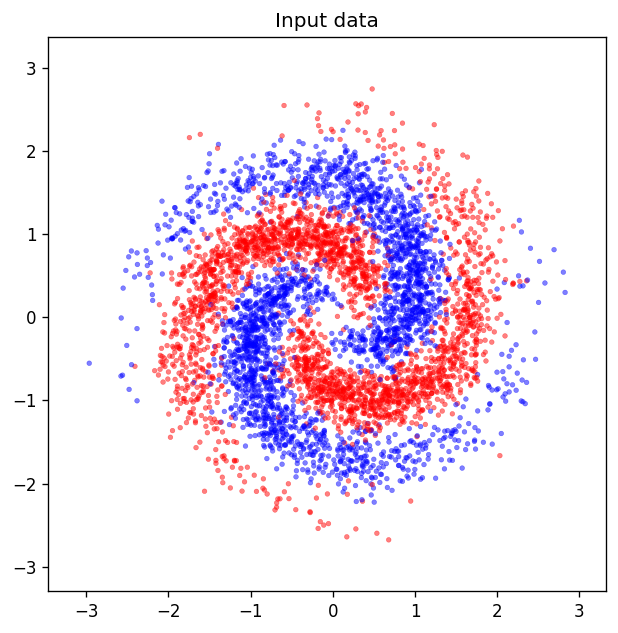

In [91]:
n_max = 5000
fig, ax = plt.subplots(figsize=(6, 6), dpi=dpis)
ax.set_title("Input data")
ax.scatter(X_train[:n_max, 0], X_train[:n_max, 1], c=y_train[:n_max], cmap=cm_bright, alpha=0.5, edgecolors=None, s=8, linewidth=0.3)
#ax.scatter(X_test[:n_max, 0], X_test[:n_max, 1], c=y_test[:n_max], cmap=cm_bright, edgecolors='k', s=8, linewidth=0.3)
ax.set_xlim(xx.min(), xx.max())
ax.set_ylim(yy.min(), yy.max())
plt.savefig(path+sample+'_data.png', dpi=250, bbox_inches="tight", pad_inches=0.02)
plt.show()

In [92]:
clf_dict = {
    'Linear classifier': SVC(kernel="linear", C=0.025),
    'Random forest': RandomForestClassifier(max_depth=10, n_estimators=10, max_features=1),
    'Boosted decision trees': XGBClassifier(eval_metric='logloss'),
    'Neural network, shallow': MLPClassifier(alpha=1, max_iter=5000, hidden_layer_sizes =(50)),
    'Neural network, middle': MLPClassifier(alpha=1, max_iter=5000, hidden_layer_sizes =(10,10)),
    'Neural network, deep': MLPClassifier(alpha=1, max_iter=5000, hidden_layer_sizes=(50,25,10)),
}

training:  Linear classifier
training:  Random forest
training:  Boosted decision trees


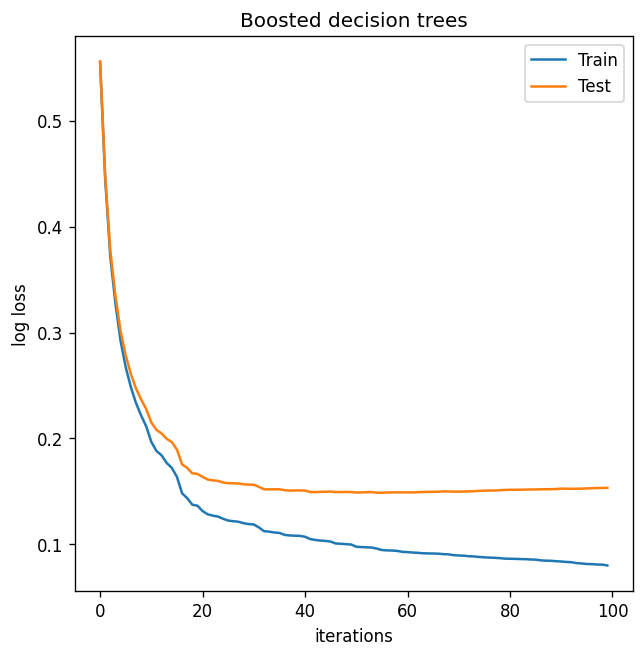

training:  Neural network, shallow


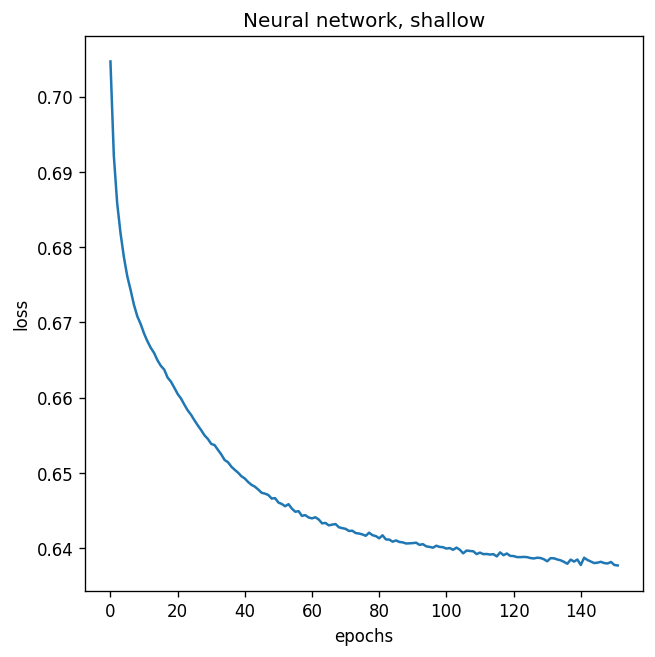

training:  Neural network, middle


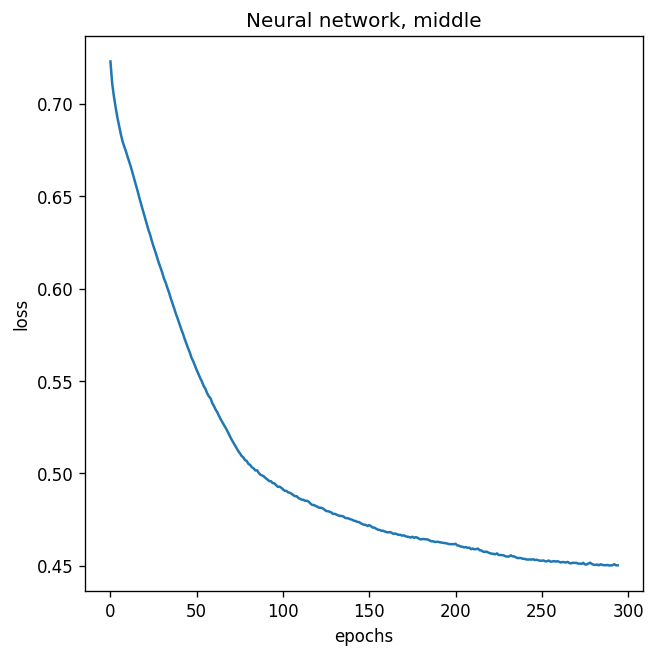

training:  Neural network, deep


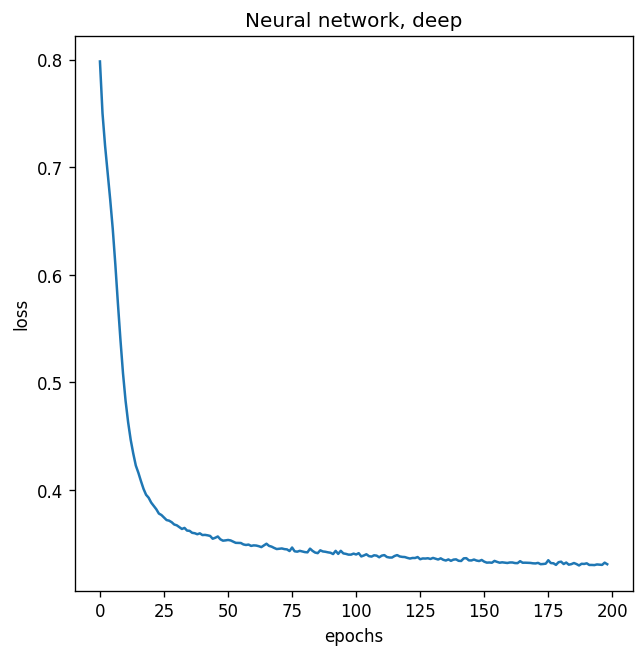

In [93]:
history = {}
for name, clf in clf_dict.items():
    print('training: ',name)
    if name == 'Boosted decision trees':
        clf.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)
        results = clf.evals_result()
        epochs = len(results['validation_0']['logloss'])
        x_axis = range(0, epochs)
        fig, ax = plt.subplots(figsize=(6,6), dpi=dpis)
        ax.plot(x_axis, results['validation_0']['logloss'], label='Train')
        ax.plot(x_axis, results['validation_1']['logloss'], label='Test')
        ax.legend()
        plt.ylabel('log loss')
        plt.xlabel('iterations')
        plt.title(name)
        plt.show()
    elif name.startswith("Neural"):
        clf.fit(X_train, y_train)
        fig, ax = plt.subplots(figsize=(6,6), dpi=dpis)
        plt.plot(clf.loss_curve_)
        plt.ylabel('loss')
        plt.xlabel('epochs')
        plt.title(name)
        plt.show()
    else:
        clf.fit(X_train, y_train)

In [94]:
from matplotlib.colors import LinearSegmentedColormap  
def gradient_dict(m, x):
    return {'red'  : ((0.0, x, x), (0.5, x, x), (1.0, m, m)),
            'green': ((0.0, m, m), (0.5, x, x), (1.0, m, m)),
            'blue' : ((0.0, m, m), (0.5, x, x), (1.0, x, x))}
mesh_col = LinearSegmentedColormap('BlueRed1', gradient_dict(0.5, 1))
cont_col = LinearSegmentedColormap('BlueRed2', gradient_dict(0.2, 0.8))

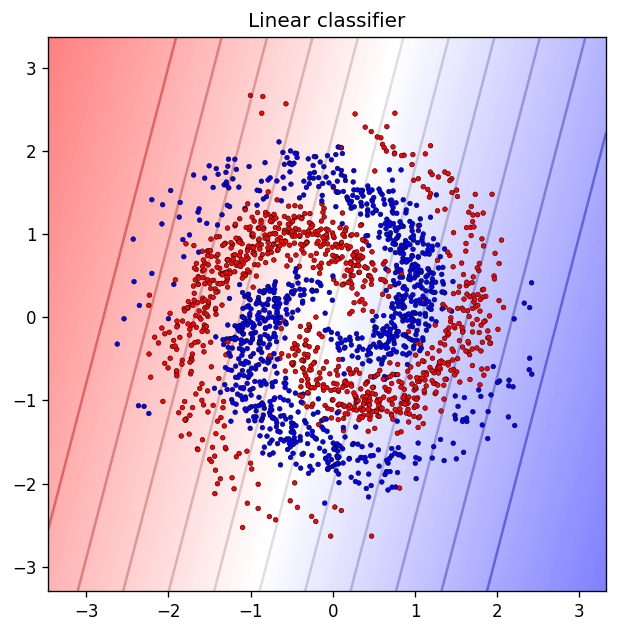

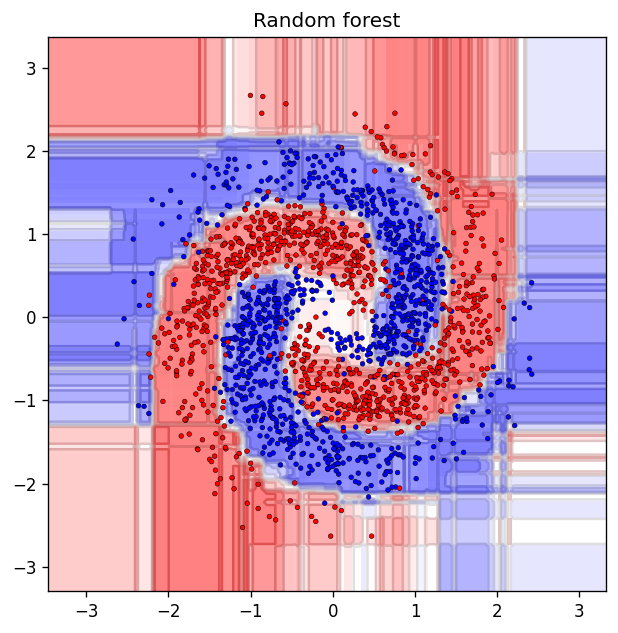

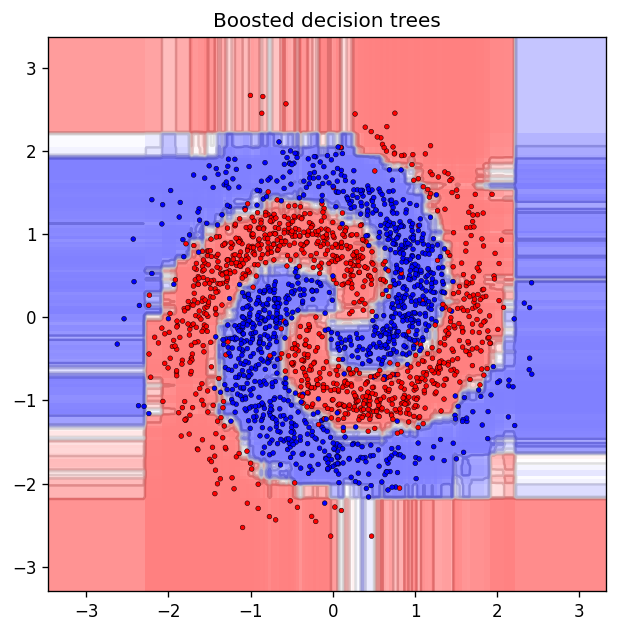

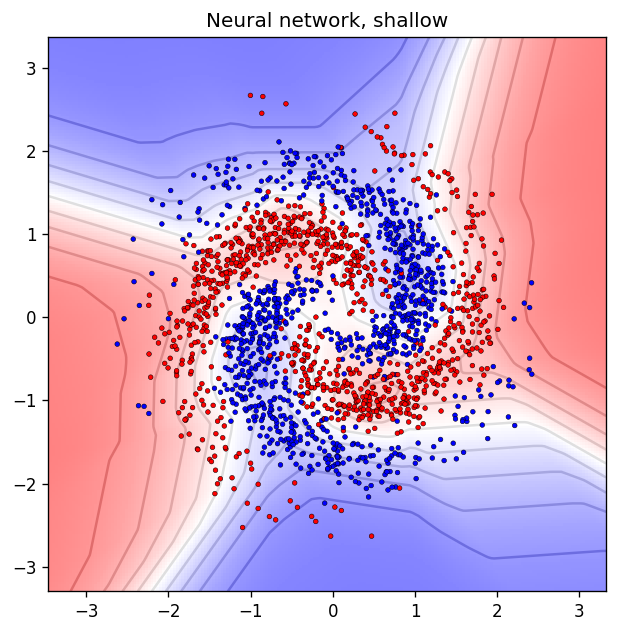

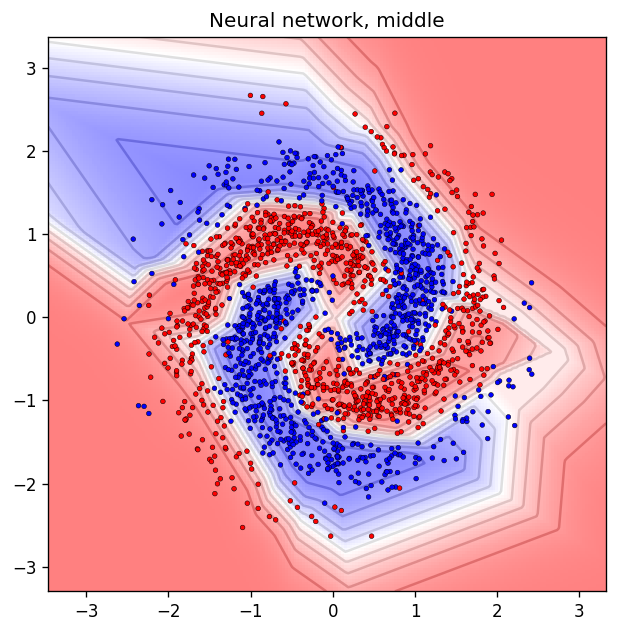

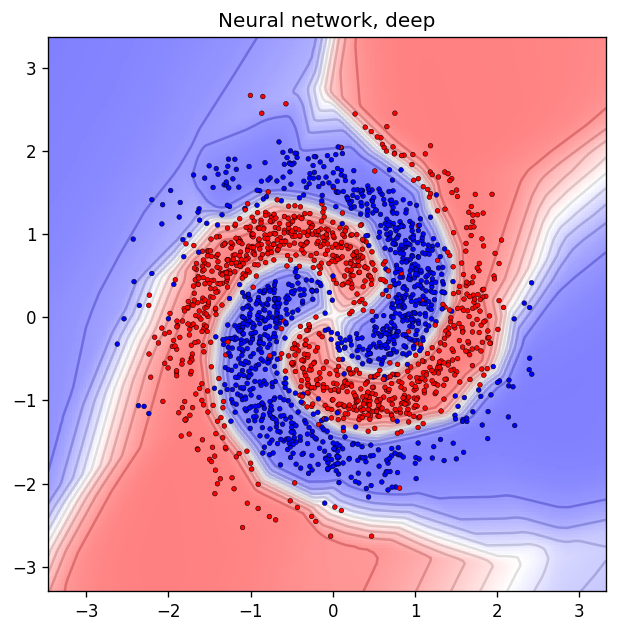

In [95]:
n_max = 2000
for name, clf in clf_dict.items():
    if hasattr(clf, "decision_function"):
        Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
        Zs = clf.decision_function(X_test).ravel()
        if name == 'SVC':
            Z += np.ones_like(Z)
            Zs += np.ones_like(Zs)        
        z_min, z_max = Zs.min(), Zs.max()
        #z_max = max(-z_min, z_max)
        #z_min = -z_max
        Z_cont = np.linspace(z_min, z_max, 11)
    else:
        Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        Z_cont = np.linspace(0, 1, 11)
    Z = Z.reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(6, 6), dpi=dpis)
    ax.pcolormesh(xx, yy, Z, cmap=mesh_col, shading='auto', zorder=0)
    ax.contour(xx, yy, Z, Z_cont, cmap=cont_col, zorder=1, alpha=0.6)
#    ax.scatter(X_train[:n_max, 0], X_train[:n_max, 1], c=y_train[:n_max], cmap=cm_bright, edgecolors="k", s=8, linewidth=0.3, alpha=0.4, zorder=10)
    ax.scatter(X_test[:n_max, 0], X_test[:n_max, 1], c=y_test[:n_max], cmap=cm_bright, edgecolors="k", s=8, linewidth=0.3, zorder=11)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(name)
    plt.savefig(path+sample+'_'+name.lower().replace(",", "").replace(" ", "_")+'_2d.png', dpi=250, bbox_inches="tight", pad_inches=0.02)
    fig.show()

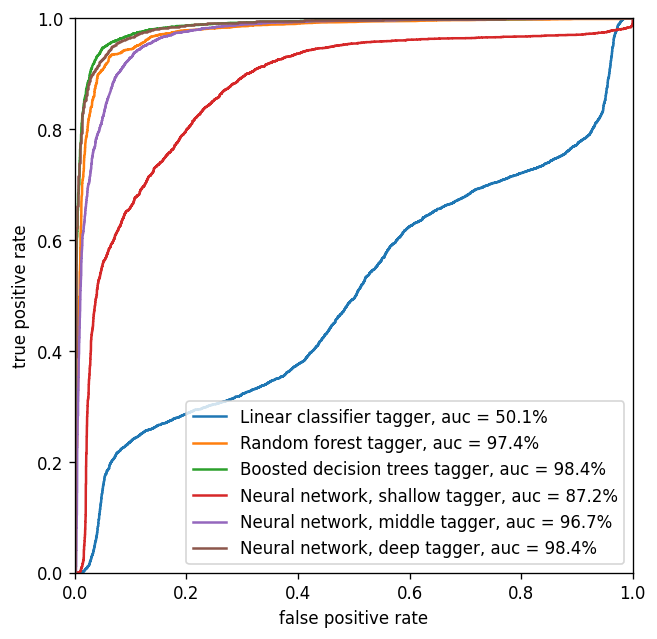

In [96]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=dpis)
for name, clf in clf_dict.items():
    if hasattr(clf, "decision_function"):
        y_pred = clf.decision_function(X_test)
    else:
        y_pred = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thr = metrics.roc_curve(y_test, y_pred)
    auc = metrics.auc(fpr, tpr)
    plt.plot(1-tpr,1-fpr,label='%s tagger, auc = %.1f%%'%(name,auc*100.))
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.set_xlabel('false positive rate')
    ax.set_ylabel('true positive rate')
    ax.legend()
plt.savefig(path+sample+'_roc.png', dpi=250, bbox_inches="tight", pad_inches=0.02)
plt.show()

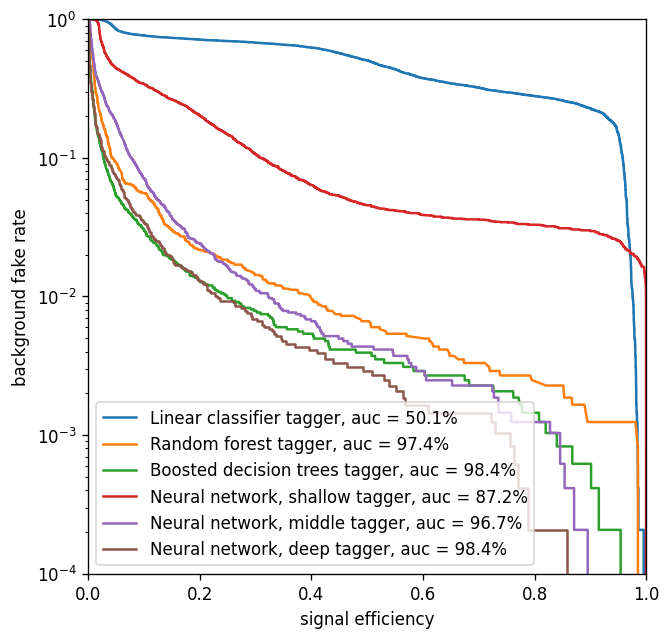

In [97]:
fig, ax = plt.subplots(figsize=(6, 6), dpi=dpis)
for name, clf in clf_dict.items():
    if hasattr(clf, "decision_function"):
        y_pred = clf.decision_function(X_test)
    else:
        y_pred = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thr = metrics.roc_curve(y_test, y_pred)
    auc = metrics.auc(fpr, tpr)
    plt.plot(1-tpr,fpr,label='%s tagger, auc = %.1f%%'%(name,auc*100.))
    ax.set_xlim(0,1)
    ax.set_ylim(1e-4,1)
    ax.set_yscale('log')
    ax.set_xlabel('signal efficiency')
    ax.set_ylabel('background fake rate')
    ax.legend()
plt.savefig(path+sample+'_roc2.png', dpi=250, bbox_inches="tight", pad_inches=0.02)
plt.show()

In [98]:
#for name, clf in clf_dict.items():
#    print(name)
#    y_pred = clf.predict(X_train)
#    from sklearn.metrics import classification_report
#    print(classification_report(y_train, y_pred, target_names=['b', 's']))

Linear classifier range: -1.0000194247390846 -0.9999854873697089


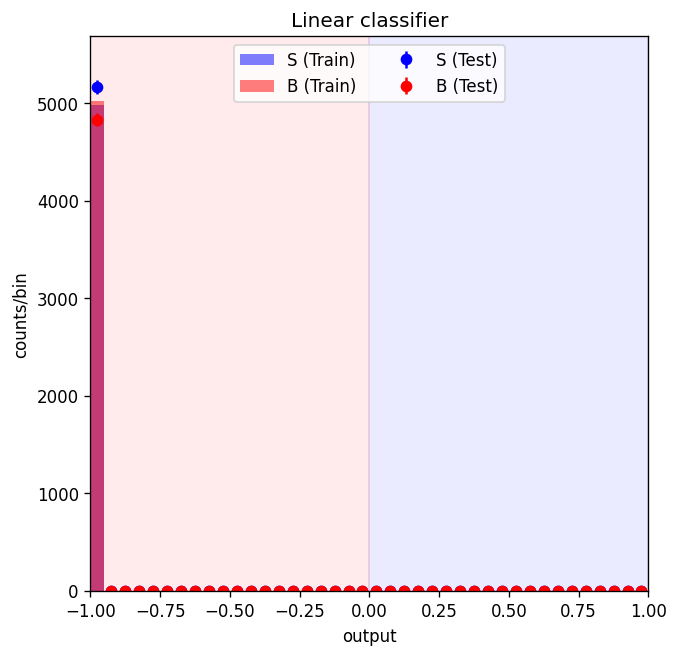

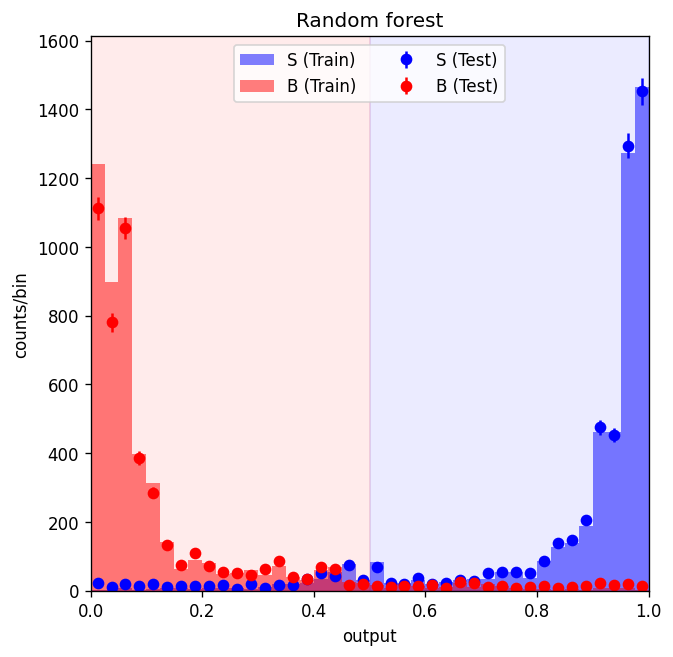

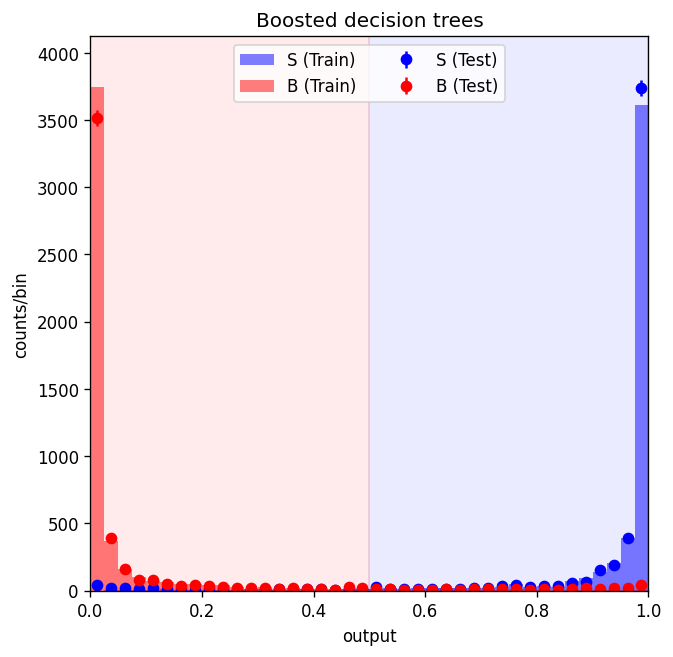

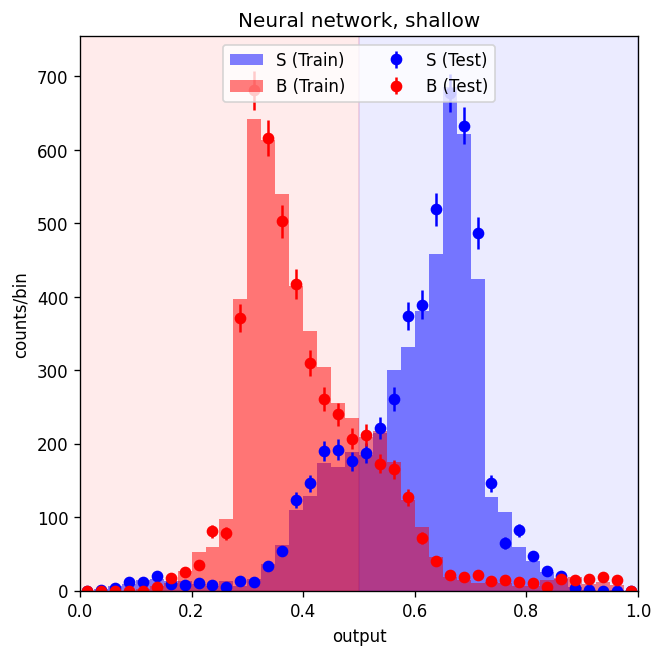

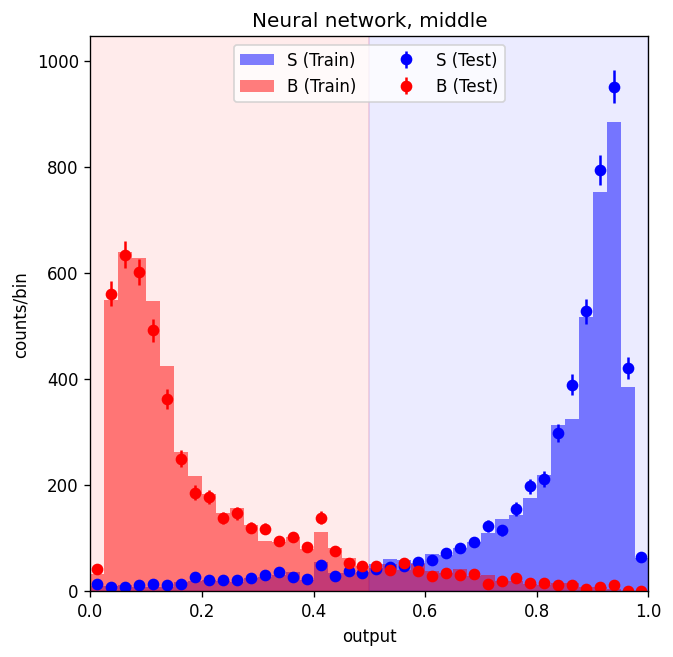

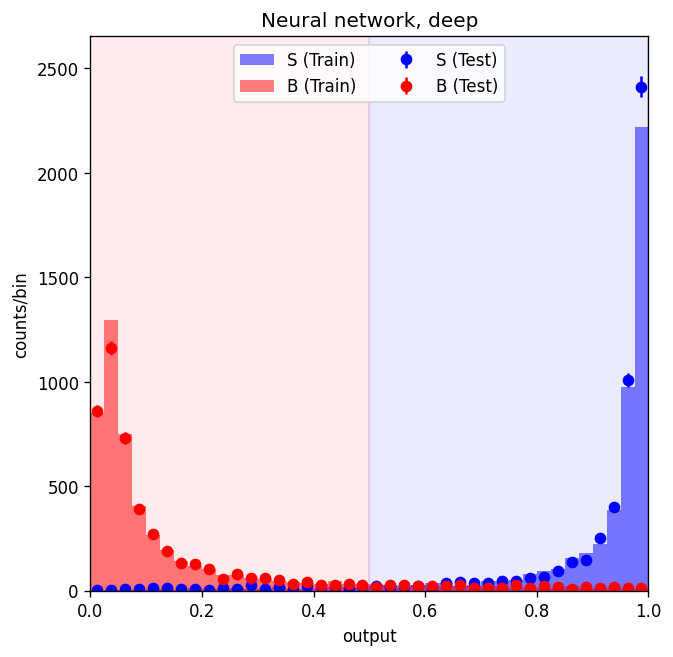

In [99]:
for name, clf in clf_dict.items():
    if hasattr(clf, "decision_function"):
        clf_train_s = clf.decision_function(X_train[y_train>0.5]).ravel()
        clf_train_b = clf.decision_function(X_train[y_train<0.5]).ravel()
        clf_test_s = clf.decision_function(X_test[y_test>0.5]).ravel()
        clf_test_b = clf.decision_function(X_test[y_test<0.5]).ravel()
        if name == 'Linear SVC' and sample == 'chess':
            clf_train_s -= np.ones_like(clf_train_s)
            clf_train_b -= np.ones_like(clf_train_b)
            clf_test_s -= np.ones_like(clf_test_s)
            clf_test_b -= np.ones_like(clf_test_b)        
        c_max = max([clf_train_s.max(), clf_train_b.max(), clf_test_s.max(), clf_test_b.max()])
        c_min = min([clf_train_s.min(), clf_train_b.min(), clf_test_s.min(), clf_test_b.min()])
        print(name, 'range:', c_min, c_max)
        if name != 'Linear SVC' and sample != 'chess':
            c_max = max(c_max, -c_min)
            c_min = -c_max
        c_cut = (c_min+c_max)/2 #0
    else:
        clf_train_s = clf.predict_proba(X_train[y_train>0.5])[:, 1].ravel()
        clf_train_b = clf.predict_proba(X_train[y_train<0.5])[:, 1].ravel() 
        clf_test_s = clf.predict_proba(X_test[y_test>0.5])[:, 1].ravel()
        clf_test_b = clf.predict_proba(X_test[y_test<0.5])[:, 1].ravel()
        c_max = 1.0
        c_min = 0.0
        c_cut = 0.5

    h_train_s = np.histogram(clf_train_s, bins=40, range=(c_min, c_max))
    h_train_b = np.histogram(clf_train_b, bins=40, range=(c_min, c_max))
    h_test_s = np.histogram(clf_test_s, bins=40, range=(c_min, c_max))
    h_test_b = np.histogram(clf_test_b, bins=40, range=(c_min, c_max))

    h_all= [h_train_s, h_train_b, h_test_s, h_test_b]
    h_max = max([h[0].max() for h in h_all])*1.1
    h_min = 0

    bin_edges = h_train_s[1]
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2.
    bin_widths = (bin_edges[1:] - bin_edges[:-1])

    err_test_s = np.sqrt(h_test_s[0])
    err_test_b = np.sqrt(h_test_b[0])
    fig, ax = plt.subplots(figsize=(6, 6), dpi=dpis)
    ax.bar(bin_centers,h_train_s[0],facecolor='blue',linewidth=0,width=bin_widths,label='S (Train)',alpha=0.5)
    ax.bar(bin_centers,h_train_b[0],facecolor='red',linewidth=0,width=bin_widths,label='B (Train)',alpha=0.5)
    ax.errorbar(bin_centers, h_test_s[0], yerr=err_test_s, xerr=None, ecolor='blue',c='blue',fmt='o',label='S (Test)')
    ax.errorbar(bin_centers, h_test_b[0], yerr=err_test_b, xerr=None, ecolor='red',c='red',fmt='o',label='B (Test)')
    ax.axvspan(c_cut, c_max, color='blue',alpha=0.08)
    ax.axvspan(c_min, c_cut, color='red',alpha=0.08)
    ax.axis([c_min, c_max, h_min, h_max])
    plt.title(name)
    plt.xlabel("output")
    plt.ylabel("counts/bin")
    legend = ax.legend(loc='upper center', ncol=2)
    plt.savefig(path+sample+'_'+name.lower().replace(",", "").replace(" ", "_")+'_1d.png', dpi=250, bbox_inches="tight", pad_inches=0.02)
    plt.show()

## Convolutional Neural Network

Permettono di modellizzare dati con strutture invarianti per traslazioni in una o più dimensioni.
* una dimensione $\rightarrow$ audio
* due dimensioni $\rightarrow$ immagini 
* ...

Un *kernel* di dimensione ridotta (es.: $3\times 3$, $5\times 5$ o $9\times 9$ pixel) viene applicato in tutte le posizioni possibili nella fase di training. Diversi kernel identificano feature non banali (es.: bordi, punti, tratti, ecc.). Il procedimento viene ripetuto in diversi layer per identificare features via via più complesse.

<img style="width: 400px" src="img/cnn-f11.png"><img style="width: 400px" src="img/cnn-f12.png">
<img style="width: 400px" src="img/cnn-f21.png"><img style="width: 400px" src="img/cnn-f22.png">


<img style="width: 400px" src="img/cnn-f3d.png">

La stessa struttura a kernel viene replicata in diversi layer, e alla fine uno o più layer completamente connesso completa la classificazione analizzando le features di alto livello.
<img style="width: 700px" src="img/cnn.png">

## Diverse strutture di Neural Network

È possibile organizzare una rete neurale per analizzare dati con strutture particolari:
* immagini: organizzate in matrici
* grafi con nodi e collegamentri tra nodi
* sequenze

Questi danno luogo ad algoritmi particolari come **Convolutional Neural Network**, **Graph Neural Network**, **Recurrent Neural Network**.

## Un esemio più complesso: riduzione del rumore e reti generative

Una rete neurale può essere addestrata per rimuovere del rumore aggiunto artificialmente ad un'immagine.
Il target del training è l'immagine originale senza rumore, oppure direttamente il rumore che è stato aggiunto.

In questo caso l'output della rete ha la stessa dimensionalità dell'immagine di input, non semplicemente un sì/no oppure una delle possibili *labels*.

Nei modelli di tipo *diffusion* la rete viene addestrata a prevedere il rumore presente nell'immagine, in modo da poterlo sottrarre progressivamente.

Dopo il training si può partire da un'immagine completamente casuale (rumore puro) e applicare iterativamente la rete per ridurre il rumore.
Durante questo processo emergono strutture compatibili con le immagini usate nel training.

Questo è un esempio semplice di rete generativa.

Per poter controllare la generazione (ad esempio: genera un cane oppure genera un gatto) si aggiunge alla rete un'informazione di condizionamento, tipicamente una *label* o una descrizione testuale.

Un'altra famiglia di modelli generativi è quella delle GAN (*Generative Adversarial Networks*), in cui una rete generativa viene addestrata per produrre immagini realistiche mentre una seconda rete cerca di distinguere immagini vere da immagini generate artificialmente.

## Reti generative

Le reti neurali addestrate possono anche essere usate, al ritroso, per generare campioni di dati verosimili dato il valore delle label attese.
Questi metodi non saranno discussi in questo notebook, ma stanno diventando sempre più attuali.

# Applicazioni:

* [Restauro e integrazione di epigrafi antiche](https://www.nature.com/articles/s41586-022-04448-z)

Immagine presa sotto i portici di via dei Tribunali:
<a href="img/neapolis-greek-inscription.jpg"><img style="width:400px" src="img/neapolis-greek-inscription.jpg"></a>

Testo trascritto sul database [Searchable Greek Inscriptions](https://inscriptions.packhum.org/text/177640?hs=108-121), 
Cornell University
Ohio State University:

    επιμεληθεντων πανερωτος και συβαριδος αντωνιας σεβαστης απελευθερων

Attribuzione sul sito [Ithaca](https://ithaca.deepmind.com/)
* 99.2%: Magna Grecia
* 99.9%: 30-40 AD 

*Caveat*: molto probabilmente l'iscrizione fa parte del campione usato per fare il training, quindi le percentuali potrebbero essere sovrastimate.

Si ringraziano gli autori Thea Sommerschield e Yannis Assael

## Applicazioni recenti e molto diffuse

*Attenzione:* il settore dell’intelligenza artificiale evolve molto rapidamente. Nuovi modelli e servizi compaiono continuamente, e le classifiche di popolarità cambiano nel giro di pochi mesi. **Per questo, questa lista è stata aggiornata da AI**.

Oggi sono particolarmente diffusi i modelli generativi multimodali, capaci di lavorare con testo, immagini, audio, codice e video.

### Chatbot e assistenti AI

* [ChatGPT](https://chatgpt.com) — assistente generalista molto diffuso, con supporto per testo, immagini, voce e programmazione.
* [Claude AI](https://claude.ai) — noto soprattutto per scrittura, analisi di testi lunghi e coding.
* [Google Gemini](https://gemini.google.com) — integrato nell’ecosistema Google, con funzionalità multimodali avanzate.
* [Microsoft Copilot](https://copilot.microsoft.com) — integrato nei servizi Microsoft e in Windows.
* [DeepSeek](https://www.deepseek.com) — molto popolare per capacità logiche e disponibilità gratuita.
* [Perplexity AI](https://www.perplexity.ai) — orientato alla ricerca sul web con citazioni delle fonti.
* [Grok](https://grok.x.ai) — chatbot sviluppato da xAI e integrato nella piattaforma X/Twitter.

### Generazione di immagini

* [Midjourney](https://www.midjourney.com) — molto usato per immagini artistiche e stilizzate.
* [Stable Diffusion](https://stability.ai/stable-image) — famiglia di modelli open source molto flessibile.
* [DALL·E / GPT Image](https://openai.com/index/image-generation/) — integrato in ChatGPT per generazione e modifica di immagini.
* [Google Gemini Image Generation (“Nano Banana”)](https://gemini.google/overview/image-generation/) — noto per fotorealismo e buona gestione del testo nelle immagini.
* [Adobe Firefly](https://firefly.adobe.com) — orientato alla grafica e all’integrazione con Photoshop e Creative Cloud.
* [FLUX](https://blackforestlabs.ai) — modelli recenti molto apprezzati per qualità e personalizzazione.

### Video generativi

* [Runway](https://runwayml.com) — uno dei servizi più usati per video AI.
* [OpenAI Sora](https://openai.com/sora/) — generazione video da prompt testuali.
* [Pika Labs](https://pika.art) — creazione rapida di brevi video generativi.
* [Luma AI Dream Machine](https://lumalabs.ai/dream-machine) — specializzato in video realistici e animazioni.

### Modelli open source e locali

* [Llama (Meta)](https://www.llama.com)
* [Mistral AI](https://mistral.ai)
* [Ollama](https://ollama.com) — permette di eseguire modelli AI localmente sul proprio computer.

Negli ultimi anni si è assistito anche alla diffusione di modelli open source eseguibili localmente, spesso tramite strumenti come Ollama o LM Studio.

### Alcune applicazioni significative dell’AI e del machine learning

Nel corso degli ultimi anni, le tecniche di intelligenza artificiale e *machine learning* hanno trovato applicazioni in moltissimi campi, dalla produzione cinematografica alla ricerca scientifica.

#### Cinema, immagini e multimedia

* [Adattamento automatico del movimento delle labbra al doppiaggio](https://www.flawlessai.com/) — tecniche di AI generativa usate nella post-produzione cinematografica.
* [Restauro e aumento di risoluzione di filmati storici](https://youtu.be/hZ1OgQL9_Cw) — miglioramento di qualità, stabilizzazione e interpolazione dei fotogrammi.
    * [Topaz Video AI](https://www.topazlabs.com/) — software commerciale molto usato per upscaling e restauro video.
* [Trasferimento dello stile pittorico a immagini e video](https://youtu.be/eghGQtQhY38) — una delle applicazioni classiche delle reti neurali convoluzionali.
* [Generazione di immagini e video realistici](https://openai.com/sora/) — modelli recenti consentono di creare contenuti sintetici sempre più credibili.

#### Videogiochi e apprendimento automatico

* [Apprendimento automatico applicato ai videogiochi classici](https://youtu.be/EfGD2qveGdQ) — agenti AI possono imparare a giocare autonomamente tramite *reinforcement learning*.
* [AlphaGo sconfigge il campione mondiale di Go](https://youtu.be/WXuK6gekU1Y) (2016) — uno degli eventi simbolo dello sviluppo moderno dell’AI.

#### Applicazioni nella fisica delle particelle

* [Ricerca della supersimmetria](https://cerncourier.com/a/deep-learning-tailors-supersymmetry-searches/) — utilizzo di tecniche di *deep learning* per ottimizzare la selezione degli eventi.
* [Ricerca di anomalie potenzialmente associate alla materia oscura](https://link.springer.com/article/10.1007/JHEP02(2022)074) — uso di algoritmi non supervisionati e reti neurali.
* [Identificazione delle particelle che producono jet](https://arxiv.org/abs/1908.08256) — classificazione avanzata basata su reti neurali profonde.
* Oggi una parte significativa degli articoli di fisica delle particelle utilizza, in qualche forma, tecniche di *machine learning* o AI per analisi dati, simulazioni o ricostruzione degli eventi.

# Esercizio:

Usare algoritmi di Machine Learning per prevedere se un passeggero del Titanic sarebbe sopravvissuto o meno al naufragio.

Il campione dei dati è fornit, separato in un campione di test ed uno di training, sul sito di [kaggle](https://www.kaggle.com/), dove si trovano dicersi *challenge* per applicazioni di Machine Learning:

*  https://www.kaggle.com/c/titanic/data